<a href="https://colab.research.google.com/github/Geethanjali295/Crop-Yield-prediction-/blob/main/Copy_of_Final_project_crop2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/crop_yield.csv')
df

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251
...,...,...,...,...,...,...,...,...,...,...
999995,West,Silt,Rice,302.805345,27.987428,False,False,Sunny,76,1.347586
999996,South,Chalky,Barley,932.991383,39.661039,True,False,Rainy,93,7.311594
999997,North,Peaty,Cotton,867.362046,24.370042,True,False,Cloudy,108,5.763182
999998,West,Silt,Wheat,492.812857,33.045505,False,False,Sunny,102,2.070159


In [ ]:
df = df[df['Yield_tons_per_hectare'] >= 0].copy()
print("DataFrame after removing negative yield values:")
display(df.head())
print(f"New DataFrame shape: {df.shape}")

DataFrame after removing negative yield values:


,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare,Temperature_Category,Rainfall_Category
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816,Medium Temperature,High Rainfall
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341,Low Temperature,High Rainfall
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443,Medium Temperature,Low Rainfall
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573,Low Temperature,High Rainfall
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251,High Temperature,High Rainfall


New DataFrame shape: (999769, 12)


In [ ]:
print("Updated DataFrame description after removing negative yield values:")
display(df.describe())

Updated DataFrame description after removing negative yield values:


,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,999769.000000,999769.000000,999769.000000,999769.000000
mean,550.077823,27.506079,104.495141,4.650592
std,259.804329,7.220488,25.953328,1.695166
min,100.000896,15.000034,60.000000,0.000411
25%,325.062906,21.256078,82.000000,3.418669
50%,550.229205,27.509509,104.000000,4.652333
75%,774.797949,33.754459,127.000000,5.879576
max,999.998098,39.999997,149.000000,9.963372


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999769 entries, 0 to 999999
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Rainfall_mm               999769 non-null  float64
 1   Temperature_Celsius       999769 non-null  float64
 2   Fertilizer_Used           999769 non-null  int64  
 3   Irrigation_Used           999769 non-null  int64  
 4   Days_to_Harvest           999769 non-null  int64  
 5   Yield_tons_per_hectare    999769 non-null  float64
 6   Soil_Type_Chalky          999769 non-null  int64  
 7   Soil_Type_Clay            999769 non-null  int64  
 8   Soil_Type_Loam            999769 non-null  int64  
 9   Soil_Type_Peaty           999769 non-null  int64  
 10  Soil_Type_Sandy           999769 non-null  int64  
 11  Soil_Type_Silt            999769 non-null  int64  
 12  Weather_Condition_Cloudy  999769 non-null  int64  
 13  Weather_Condition_Rainy   999769 non-null  int64 

In [ ]:
df.isnull().sum()

,0
Region,0
Soil_Type,0
Crop,0
Rainfall_mm,1
Temperature_Celsius,1
Fertilizer_Used,1
Irrigation_Used,1
Weather_Condition,1
Days_to_Harvest,1
Yield_tons_per_hectare,1


In [ ]:
df['Days_to_Harvest'] = df['Days_to_Harvest'].fillna(df['Days_to_Harvest'].mean())
df['Yield_tons_per_hectare'] = df['Yield_tons_per_hectare'].fillna(df['Yield_tons_per_hectare'].mean())
df['Temperature_Celsius'] = df['Temperature_Celsius'].fillna(df['Temperature_Celsius'].mean())
df['Weather_Condition'] = df['Weather_Condition'].fillna(df['Weather_Condition'].mode()[0])
df['Irrigation_Used'] = df['Irrigation_Used'].fillna(df['Irrigation_Used'].mode()[0])
df['Fertilizer_Used'] = df['Fertilizer_Used'].fillna(df['Fertilizer_Used'].mode()[0])
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].mean())

In [ ]:
df.isnull().sum()

,0
Region,0
Soil_Type,0
Crop,0
Rainfall_mm,0
Temperature_Celsius,0
Fertilizer_Used,0
Irrigation_Used,0
Weather_Condition,0
Days_to_Harvest,0
Yield_tons_per_hectare,0


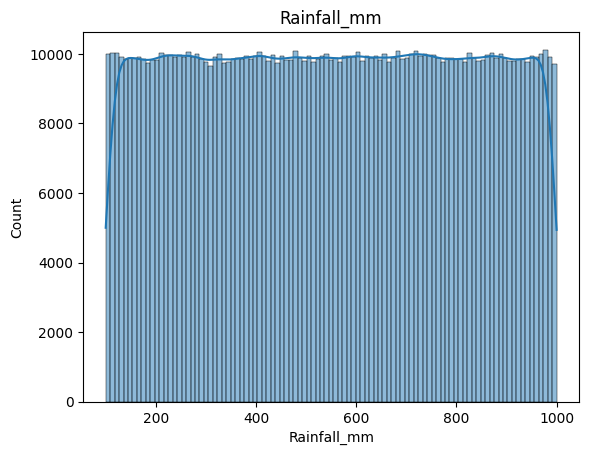

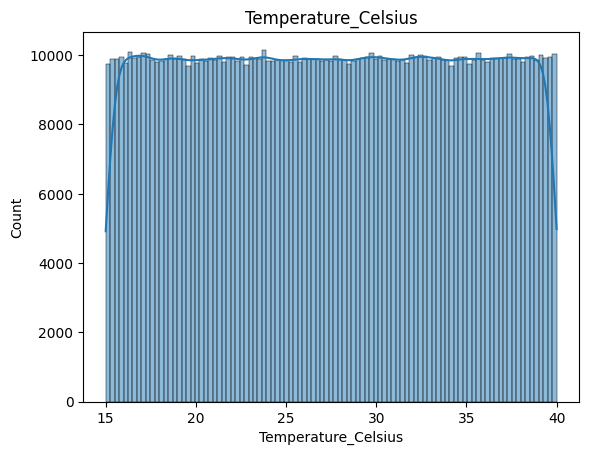

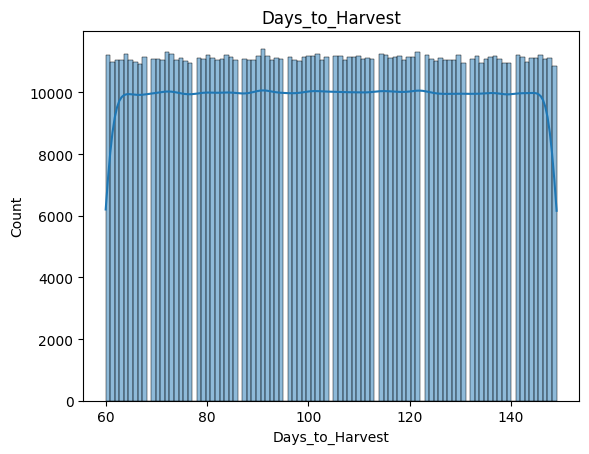

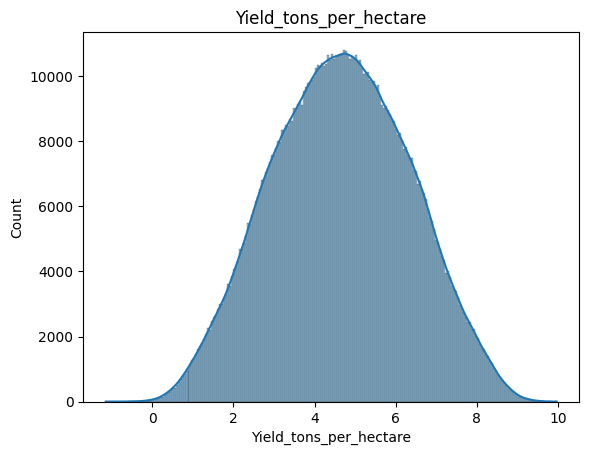

In [ ]:
numerical_cols=df.select_dtypes(include=np.number).columns
numerical_cols
for col in numerical_cols:
  sns.histplot(df[col],kde=True)
  plt.title(col)
  plt.show()

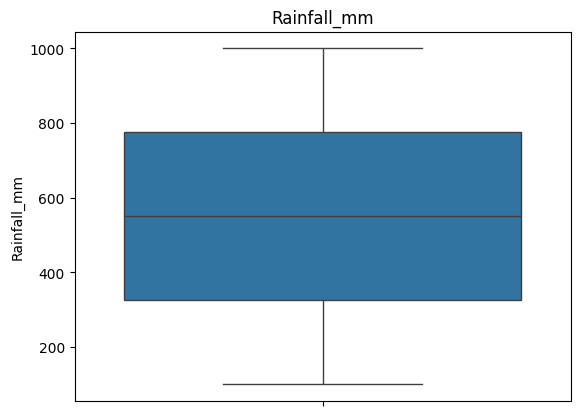

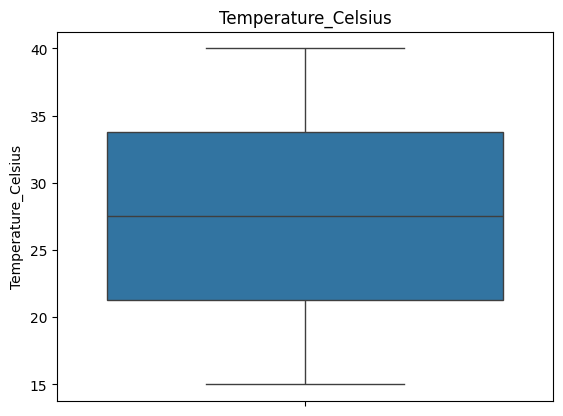

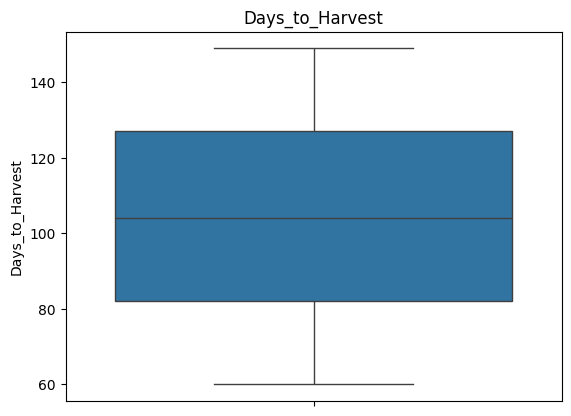

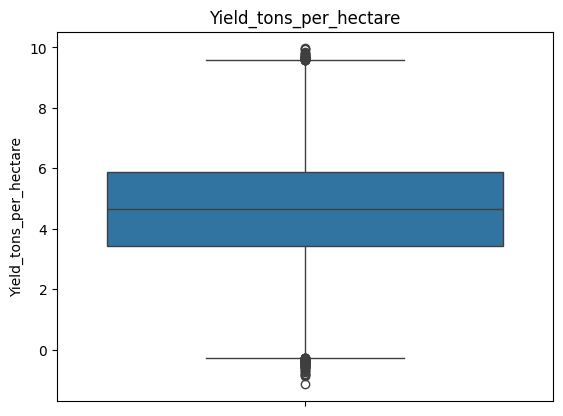

In [ ]:
numerical_cols=df.select_dtypes(include=np.number).columns
numerical_cols
for col in numerical_cols:
  sns.boxplot(df[col])
  plt.title(col)
  plt.show()

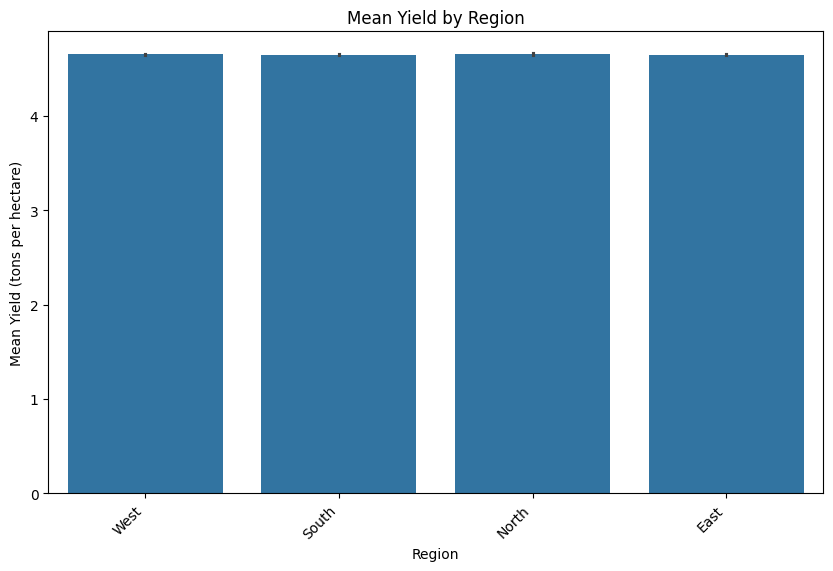

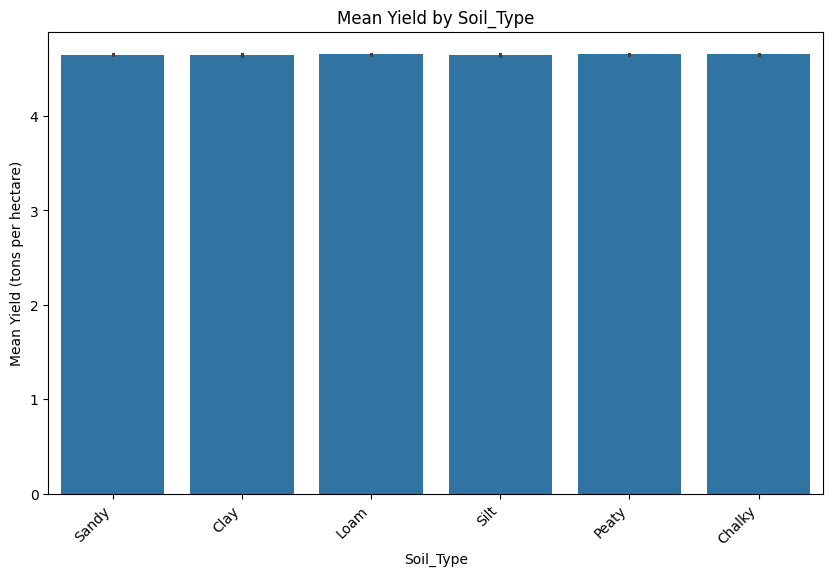

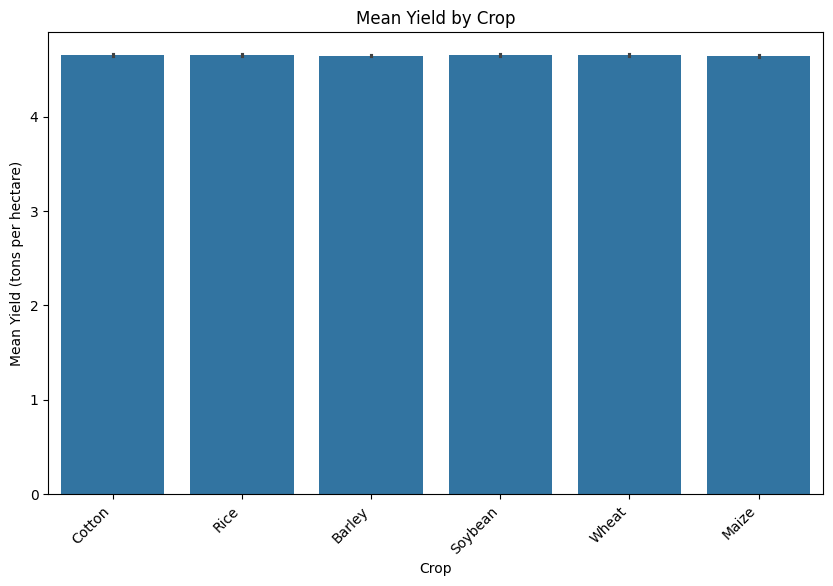

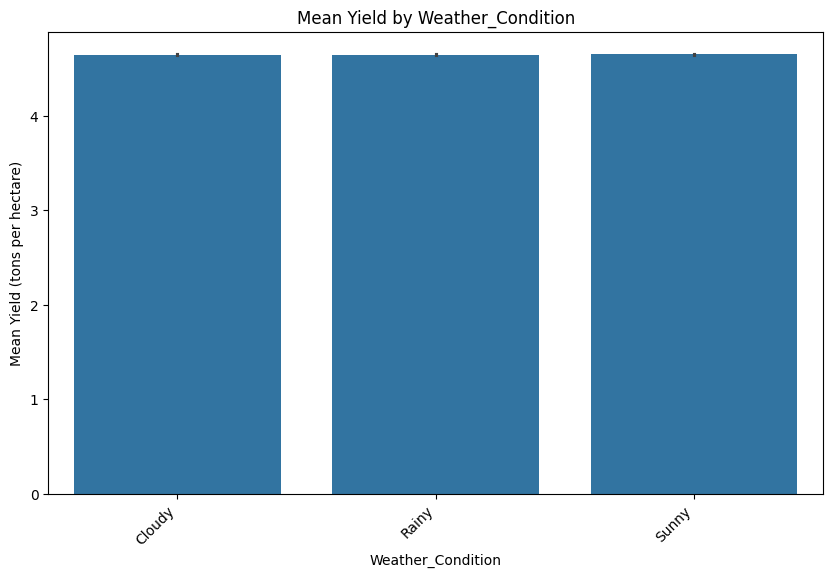

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ['Region', 'Soil_Type', 'Crop', 'Weather_Condition']

for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=col, y='Yield_tons_per_hectare', data=df)
    plt.title(f'Mean Yield by {col}')
    plt.xlabel(col)
    plt.ylabel('Mean Yield (tons per hectare)')
    plt.xticks(rotation=45, ha='right')
    plt.show()

In [ ]:
from scipy.stats import skew
for col in numerical_cols:
  print(col)
  print(skew(df[col]))

Rainfall_mm
-0.00023170416261707546
Temperature_Celsius
-0.0008819979698115169
Days_to_Harvest
0.007144312396269119
Yield_tons_per_hectare
-0.0026248804798038997


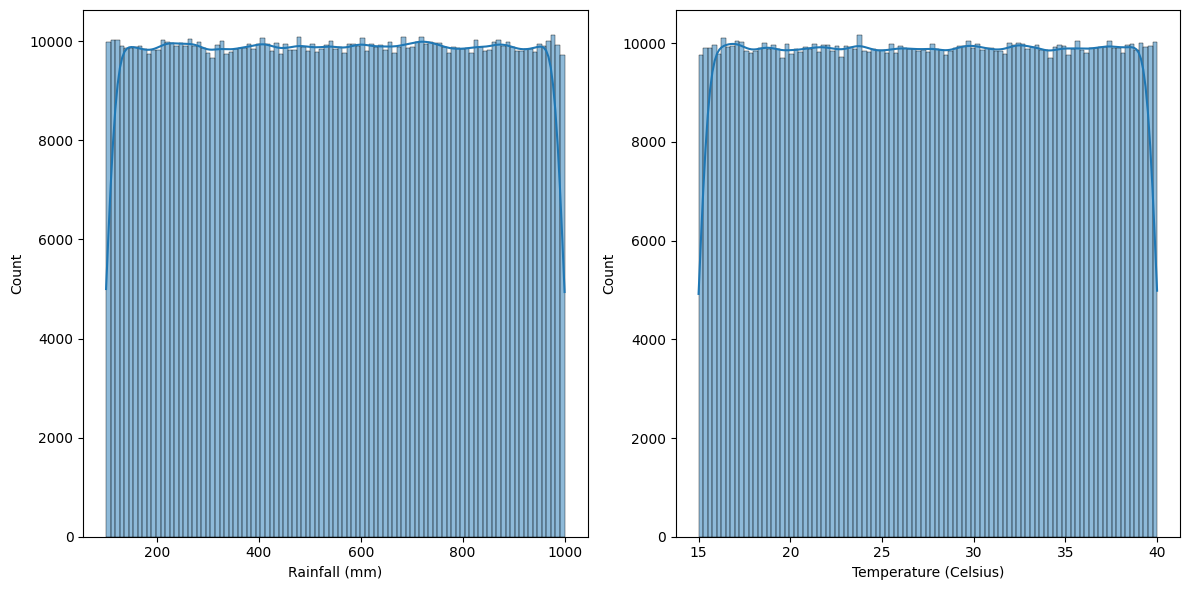

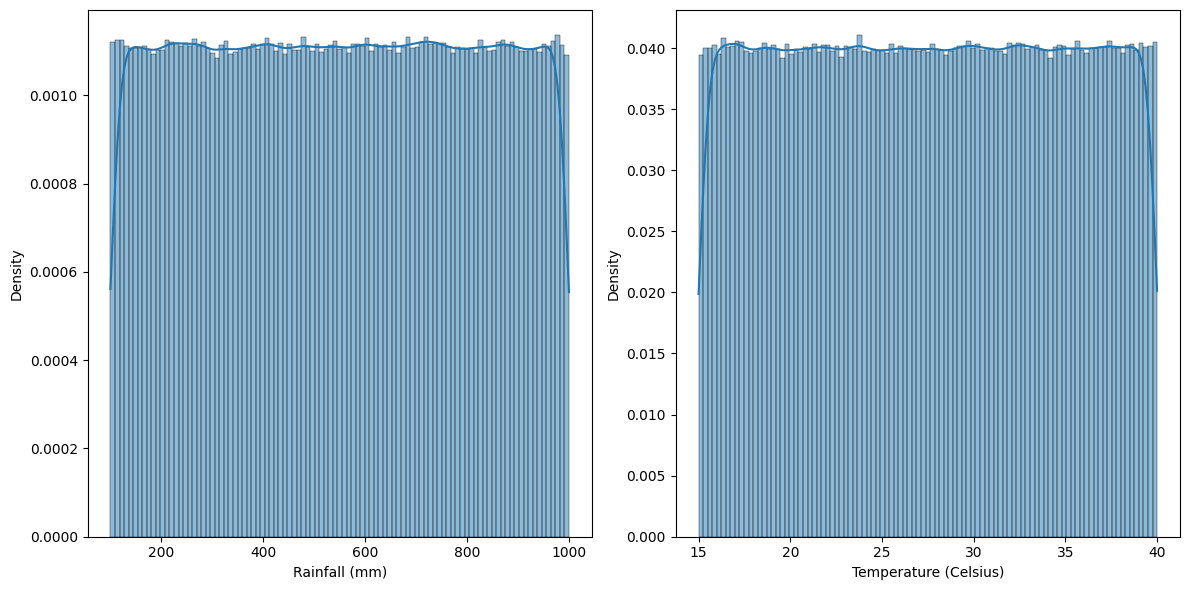

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['Rainfall_mm'], kde=True)
plt.xlabel('Rainfall (mm)')
plt.ylabel('Count')

# Original histplot showing counts for Temperature_Celsius
plt.subplot(1, 2, 2)
sns.histplot(df['Temperature_Celsius'], kde=True)
plt.xlabel('Temperature (Celsius)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Normalized histplot showing density for Rainfall_mm
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['Rainfall_mm'], kde=True, stat='density')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Density')

# Normalized histplot showing density for Temperature_Celsius
plt.subplot(1, 2, 2)
sns.histplot(df['Temperature_Celsius'], kde=True, stat='density')
plt.xlabel('Temperature (Celsius)')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

<Axes: >

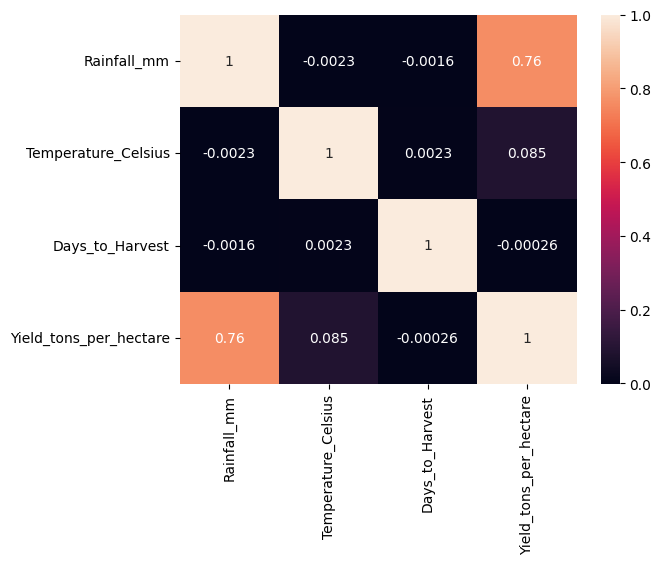

In [ ]:
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True)

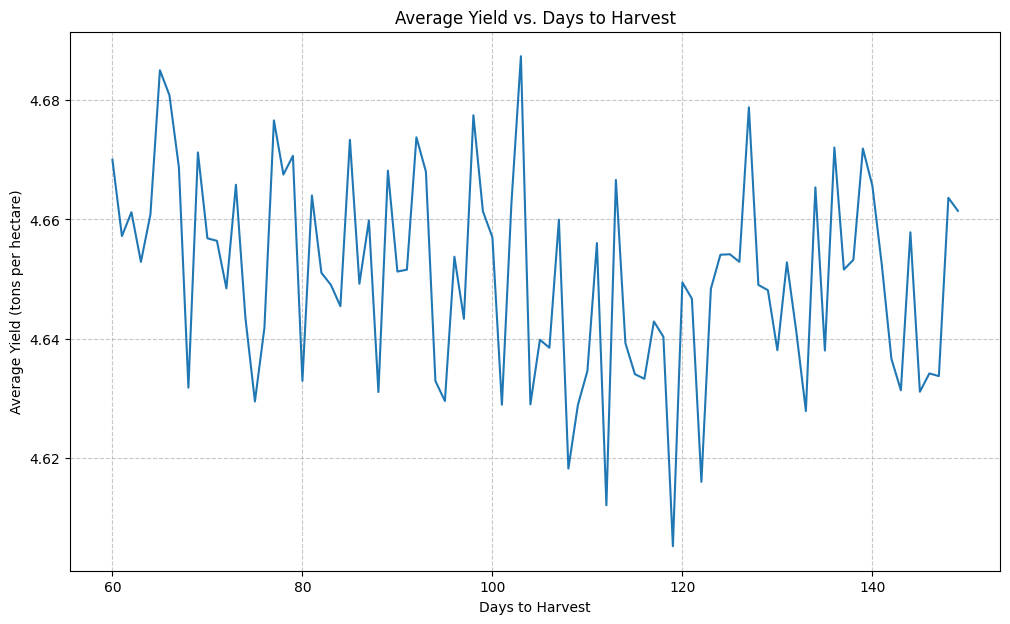

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by 'Days_to_Harvest' and calculate the mean 'Yield_tons_per_hectare'
yield_trend_data = df.groupby('Days_to_Harvest')['Yield_tons_per_hectare'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.lineplot(x='Days_to_Harvest', y='Yield_tons_per_hectare', data=yield_trend_data)
plt.title('Average Yield vs. Days to Harvest')
plt.xlabel('Days to Harvest')
plt.ylabel('Average Yield (tons per hectare)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from scipy.stats import f_oneway

categorical_cols = ['Region', 'Soil_Type', 'Crop', 'Weather_Condition']

for col in categorical_cols:
    print(f"\n ANOVA for {col} and Yield_tons_per_hectare")

    # Prepare groups, ensuring no NaN and at least 2 groups
    groups = [df[df[col] == val]['Yield_tons_per_hectare'].dropna() for val in df[col].unique() if len(df[df[col] == val].dropna()) > 1]

    if len(groups) < 2:
        print(f"Skipping {col}: not enough valid groups")
        continue

    # Perform one-way ANOVA
    f_stat, p_val = f_oneway(*groups)

    print(f"F-statistic: {f_stat}")
    print(f"P-value: {p_val}")



--- ANOVA for Region and Yield_tons_per_hectare ---
F-statistic: 1.0710298955795718
P-value: 0.35992377022524275

--- ANOVA for Soil_Type and Yield_tons_per_hectare ---
F-statistic: 0.460364974118186
P-value: 0.8059986906243686

--- ANOVA for Crop and Yield_tons_per_hectare ---
F-statistic: 1.1792023335340958
P-value: 0.3164701789417449

--- ANOVA for Weather_Condition and Yield_tons_per_hectare ---
F-statistic: 0.6438681672130914
P-value: 0.5252569266777116


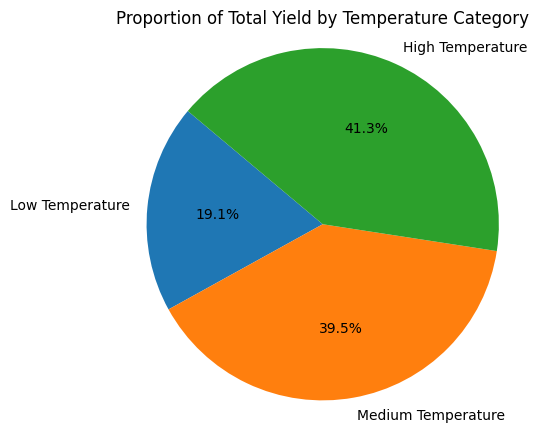

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Define temperature bins and labels
temperature_bins = [0, 20, 30, 40]  # Example bins for Low, Medium, High
temperature_labels = ['Low Temperature', 'Medium Temperature', 'High Temperature']

# Create a new categorical column based on temperature bins
df.loc[:, 'Temperature_Category'] = pd.cut(df['Temperature_Celsius'], bins=temperature_bins, labels=temperature_labels, right=False)

# Group by 'Temperature_Category' and sum the 'Yield_tons_per_hectare'
temp_yield_distribution = df.groupby('Temperature_Category', observed=False)['Yield_tons_per_hectare'].sum().reset_index()

# Prepare data for the pie chart
labels = temp_yield_distribution['Temperature_Category']
sizes = temp_yield_distribution['Yield_tons_per_hectare']

# Create a pie chart
plt.figure(figsize=(5, 5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Proportion of Total Yield by Temperature Category')
plt.show()

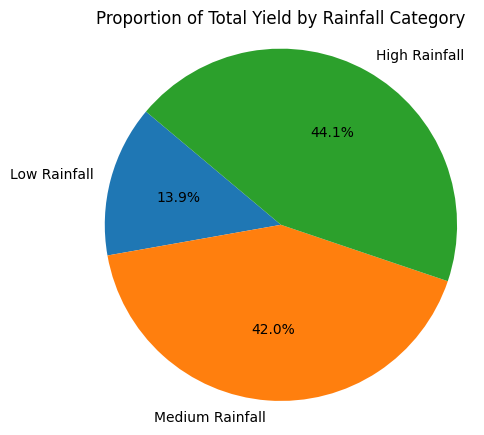

In [ ]:
rainfall_bins = [0, 300, 700, 1000]  # Example bins for Low, Medium, High rainfall
rainfall_labels = ['Low Rainfall', 'Medium Rainfall', 'High Rainfall']

# Create a new categorical column based on rainfall bins
df.loc[:,'Rainfall_Category'] = pd.cut(df['Rainfall_mm'], bins=rainfall_bins, labels=rainfall_labels, right=False)

# Group by 'Rainfall_Category' and sum the 'Yield_tons_per_hectare'
rainfall_yield_distribution = df.groupby('Rainfall_Category',observed=False)['Yield_tons_per_hectare'].sum().reset_index()

# Prepare data for the pie chart
labels = rainfall_yield_distribution['Rainfall_Category']
sizes = rainfall_yield_distribution['Yield_tons_per_hectare']

# Create a pie chart
plt.figure(figsize=(5, 5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Proportion of Total Yield by Rainfall Category')
plt.show()

In [ ]:
df = df.drop(columns=['Region'])
print("DataFrame after dropping 'Region' column:")
display(df.head())

DataFrame after dropping 'Region' column:


,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Fertilizer_Used']=le.fit_transform(df['Fertilizer_Used'])
df['Fertilizer_Used']

/tmp/ipykernel_563/2039437187.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 1 0 ... 1 0 1]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[:, 'Fertilizer_Used']=le.fit_transform(df['Fertilizer_Used'])


,Fertilizer_Used
0,0
1,1
2,0
3,0
4,1
...,...
999995,0
999996,1
999997,1
999998,0


In [ ]:
print(f"Minimum value of 'Days_to_Harvest': {df['Days_to_Harvest'].min()}")

Minimum value of 'Days_to_Harvest': 60


In [ ]:
print(f"Maximum value of 'Days_to_Harvest': {df['Days_to_Harvest'].max()}")

Maximum value of 'Days_to_Harvest': 149


In [ ]:

df['Irrigation_Used']=le.fit_transform(df['Irrigation_Used'])
df['Irrigation_Used']

/tmp/ipykernel_563/921738432.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1 1 0 ... 0 0 0]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[:, 'Irrigation_Used']=le.fit_transform(df['Irrigation_Used'])


,Irrigation_Used
0,1
1,1
2,0
3,1
4,1
...,...
999995,0
999996,0
999997,0
999998,0


In [ ]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()
df=pd.get_dummies(df,columns=['Soil_Type','Weather_Condition','Crop'])
df

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Yield_tons_per_hectare,Soil_Type_Chalky,Soil_Type_Clay,Soil_Type_Loam,Soil_Type_Peaty,...,Soil_Type_Silt,Weather_Condition_Cloudy,Weather_Condition_Rainy,Weather_Condition_Sunny,Crop_Barley,Crop_Cotton,Crop_Maize,Crop_Rice,Crop_Soybean,Crop_Wheat
0,897.077239,27.676966,0,1,122,6.555816,False,False,False,False,...,False,True,False,False,False,True,False,False,False,False
1,992.673282,18.026142,1,1,140,8.527341,False,True,False,False,...,False,False,True,False,False,False,False,True,False,False
2,147.998025,29.794042,0,0,106,1.127443,False,False,True,False,...,False,False,False,True,True,False,False,False,False,False
3,986.866331,16.644190,0,1,146,6.517573,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
4,730.379174,31.620687,1,1,110,7.248251,False,False,False,False,...,True,True,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,302.805345,27.987428,0,0,76,1.347586,False,False,False,False,...,True,False,False,True,False,False,False,True,False,False
999996,932.991383,39.661039,1,0,93,7.311594,True,False,False,False,...,False,False,True,False,True,False,False,False,False,False
999997,867.362046,24.370042,1,0,108,5.763182,False,False,False,True,...,False,True,False,False,False,True,False,False,False,False
999998,492.812857,33.045505,0,0,102,2.070159,False,False,False,False,...,True,False,False,True,False,False,False,False,False,True


In [ ]:
bool_cols=df.select_dtypes(include='bool').columns
df[bool_cols]=df[bool_cols].astype(int)
df

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Yield_tons_per_hectare,Soil_Type_Chalky,Soil_Type_Clay,Soil_Type_Loam,Soil_Type_Peaty,...,Soil_Type_Silt,Weather_Condition_Cloudy,Weather_Condition_Rainy,Weather_Condition_Sunny,Crop_Barley,Crop_Cotton,Crop_Maize,Crop_Rice,Crop_Soybean,Crop_Wheat
0,897.077239,27.676966,0,1,122,6.555816,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0
1,992.673282,18.026142,1,1,140,8.527341,0,1,0,0,...,0,0,1,0,0,0,0,1,0,0
2,147.998025,29.794042,0,0,106,1.127443,0,0,1,0,...,0,0,0,1,1,0,0,0,0,0
3,986.866331,16.644190,0,1,146,6.517573,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
4,730.379174,31.620687,1,1,110,7.248251,0,0,0,0,...,1,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,302.805345,27.987428,0,0,76,1.347586,0,0,0,0,...,1,0,0,1,0,0,0,1,0,0
999996,932.991383,39.661039,1,0,93,7.311594,1,0,0,0,...,0,0,1,0,1,0,0,0,0,0
999997,867.362046,24.370042,1,0,108,5.763182,0,0,0,1,...,0,1,0,0,0,1,0,0,0,0
999998,492.812857,33.045505,0,0,102,2.070159,0,0,0,0,...,1,0,0,1,0,0,0,0,0,1


In [ ]:
from sklearn.model_selection import train_test_split
x=df.drop(columns=['Yield_tons_per_hectare'])
y=df['Yield_tons_per_hectare']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.20,random_state=42)
x_train.shape

(799815, 20)

In [ ]:
x_train

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Soil_Type_Chalky,Soil_Type_Clay,Soil_Type_Loam,Soil_Type_Peaty,Soil_Type_Sandy,Soil_Type_Silt,Weather_Condition_Cloudy,Weather_Condition_Rainy,Weather_Condition_Sunny,Crop_Barley,Crop_Cotton,Crop_Maize,Crop_Rice,Crop_Soybean,Crop_Wheat
816419,835.288831,39.936159,1,0,77,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0
180578,867.649855,35.125782,1,0,131,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0
766106,269.615635,19.801171,1,1,67,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0
207834,923.607497,21.427055,0,0,128,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1
411634,354.781067,18.384813,1,1,96,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259242,768.400835,28.265581,1,0,123,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0
365929,121.901483,25.391717,0,0,119,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0
131969,157.470126,26.242927,1,0,111,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0
671311,696.567192,32.343886,0,0,84,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0


In [ ]:
y_test

,Yield_tons_per_hectare
352227,4.378713
30791,1.589250
479480,8.032276
55607,6.163982
493806,6.424947
...,...
172110,3.259995
159427,4.599687
772697,7.001234
777891,5.805551


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [ ]:
columns_to_scale = ['Rainfall_mm', 'Temperature_Celsius']
scaler.fit(x_train[columns_to_scale])

x_train_scaled = scaler.transform(x_train[columns_to_scale])
x_test_scaled = scaler.transform(x_test[columns_to_scale])

In [ ]:
x_train_scaled_df = pd.DataFrame(x_train_scaled, columns=columns_to_scale, index=x_train.index)

In [ ]:
x_train_scaled_df

,Rainfall_mm,Temperature_Celsius
816419,1.097792,1.721608
180578,1.222346,1.055298
766106,-1.079415,-1.067394
207834,1.437720,-0.842185
411634,-0.751624,-1.263582
...,...,...
259242,0.840349,0.105055
365929,-1.647949,-0.293019
131969,-1.511050,-0.175113
671311,0.563870,0.669963


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
rf_model=RandomForestRegressor(random_state=42)


In [ ]:
rf_model.fit(x_train,y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_predict=rf_model.predict(x_test)

In [ ]:
r2=r2_score(y_test,y_predict)
mae=mean_absolute_error(y_test,y_predict)
rmse=np.sqrt(mean_squared_error(y_test,y_predict))
print("R2 Score:",r2)
print("Mean Absolute Error:",mae)
print("Root Mean Squared Error:",rmse)

R2 Score: 0.9072339097037745
Mean Absolute Error: 0.41321089128797633
Root Mean Squared Error: 0.5174363642254444


In [ ]:
import xgboost as xgb
xgb_model=xgb.XGBRegressor(objective='reg:squarederror',n_estimators=100,random_state=42)


In [ ]:
xgb_model.fit(x_train,y_train)
y_predict_xgb=xgb_model.predict(x_test)
r2_xgb=r2_score(y_test,y_predict_xgb)
mae_xgb=mean_absolute_error(y_test,y_predict_xgb)
rmse_xgb=np.sqrt(mean_squared_error(y_test,y_predict_xgb))

In [ ]:
print(f"R2 Score: {r2_xgb}")
print(f"Mean Absolute Error: {mae_xgb}")
print(f"Root Mean Squared Error: {rmse_xgb}")

R2 Score: 0.9126961802648438
Mean Absolute Error: 0.3995802756252358
Root Mean Squared Error: 0.5008151818610639


In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(x_train, y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
y_predict_dt = dt_model.predict(x_test)

# # Calculate evaluation metrics
r2_dt = r2_score(y_test, y_predict_dt)
mae_dt = mean_absolute_error(y_test, y_predict_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_predict_dt))
print(f"Decision Tree Regressor Model Performance:")
print(f"R2 Score: {r2_dt}")
print(f"Mean Absolute Error: {mae_dt}")
print(f"Root Mean Squared Error: {rmse_dt}")

Decision Tree Regressor Model Performance:
R2 Score: 0.8152903444193089
Mean Absolute Error: 0.5827504334580282
Root Mean Squared Error: 0.7301416438605225


In [ ]:
# from sklearn.neighbors import KNeighborsRegressor
# knn_model = KNeighborsRegressor(n_neighbors=5) # Using 5 neighbors as a starting point
# knn_model.fit(x_train, y_train)
# y_predict_knn = knn_model.predict(x_test)

In [ ]:
# r2_knn = r2_score(y_test, y_predict_knn)
# mae_knn = mean_absolute_error(y_test, y_predict_knn)
# rmse_knn = np.sqrt(mean_squared_error(y_test, y_predict_knn))
# print(f"R2 Score: {r2_knn}")
# print(f"Mean Absolute Error: {mae_knn}")
# print(f"Root Mean Squared Error: {rmse_knn}")

R2 Score: 0.8486012831305305
Mean Absolute Error: 0.5257184017347485
Root Mean Squared Error: 0.6610334207514702


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Model performance metrics
model_performance = {
    'Model': [
        'XGBoost',
        'RandomForest',
        'DecisionTree',
        'KNeighbors'

    ],
    'R2 Score': [
        0.9126961802648438,
        0.9072339097037745,
        0.8152903444193089,
        0.8486012831305305
    ],
    'Mean Absolute Error': [
        0.3995802756252358,
        0.41321089128797633,
        0.5827504334580282,
        0.5257184017347485
    ],
    'Root Mean Squared Error': [
        0.5008151818610639,
        0.5174363642254444,
        0.7301416438605225,
        0.6610334207514702
    ]
}

df_performance = pd.DataFrame(model_performance)

display(df_performance)

,Model,R2 Score,Mean Absolute Error,Root Mean Squared Error
0,XGBoost,0.912696,0.399580,0.500815
1,RandomForest,0.907234,0.413211,0.517436
2,DecisionTree,0.815290,0.582750,0.730142
3,KNeighbors,0.848601,0.525718,0.661033


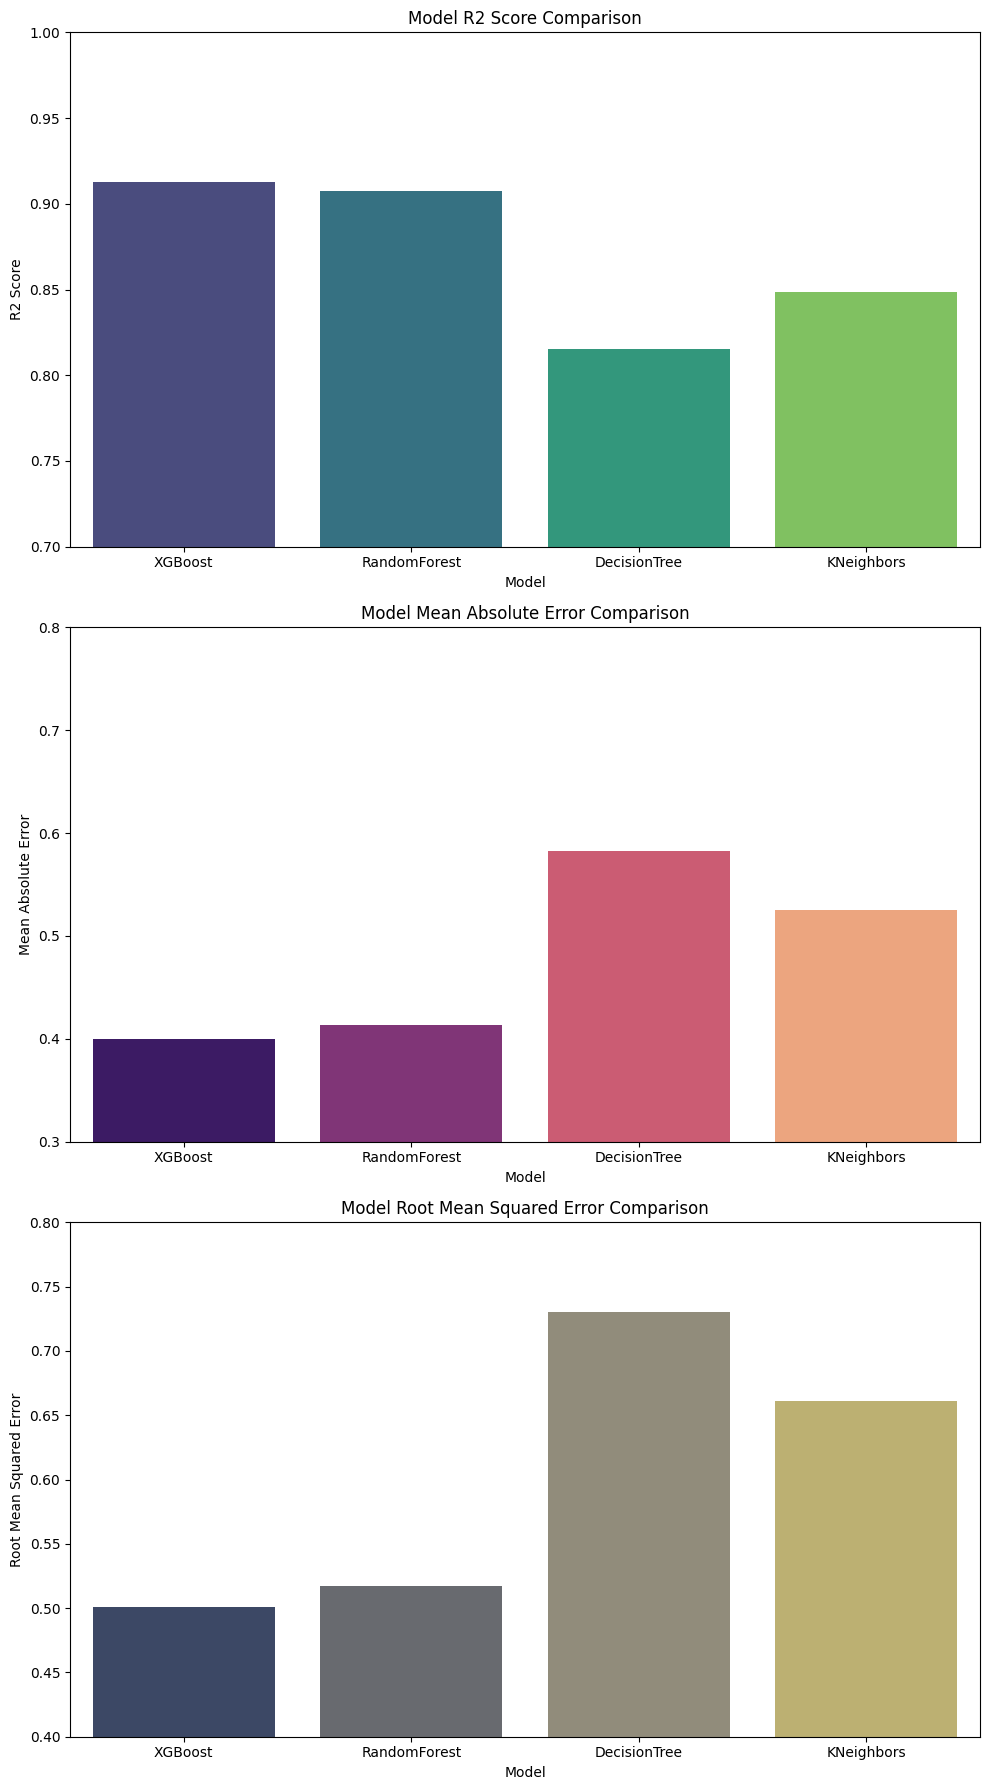

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

sns.barplot(x='Model', y='R2 Score', data=df_performance, ax=axes[0], hue='Model', palette='viridis', legend=False)
axes[0].set_title('Model R2 Score Comparison')
axes[0].set_ylim(0.7, 1.0)

sns.barplot(x='Model', y='Mean Absolute Error', data=df_performance, ax=axes[1], hue='Model', palette='magma', legend=False)
axes[1].set_title('Model Mean Absolute Error Comparison')
axes[1].set_ylim(0.3, 0.8)

sns.barplot(x='Model', y='Root Mean Squared Error', data=df_performance, ax=axes[2], hue='Model', palette='cividis', legend=False)
axes[2].set_title('Model Root Mean Squared Error Comparison')
axes[2].set_ylim(0.4, 0.8)

plt.tight_layout()
plt.show()

In [ ]:
# from sklearn.linear_model import Ridge
# from sklearn.model_selection import GridSearchCV

In [ ]:
# ridge = Ridge(random_state=42)
# param_grid = {
#     'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
# }
# grid_search_ridge = GridSearchCV(estimator=ridge, param_grid=param_grid,
#                                  cv=5, scoring='r2', n_jobs=-1, verbose=1)

# # Fit GridSearchCV to the training data
# grid_search_ridge.fit(x_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=5, estimator=Ridge(random_state=42), n_jobs=-1,
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}, scoring='r2',
             verbose=1)

In [ ]:
# print(f"Best hyperparameters for Ridge Regression: {grid_search_ridge.best_params_}")

# # Get the best model
# best_ridge_model = grid_search_ridge.best_estimator_

# # Make predictions with the best model
# y_predict_ridge = best_ridge_model.predict(x_test)

# # Evaluate the best model
# r2_ridge = r2_score(y_test, y_predict_ridge)
# mae_ridge = mean_absolute_error(y_test, y_predict_ridge)
# rmse_ridge = np.sqrt(mean_squared_error(y_test, y_predict_ridge))

# print("\n Tuned Ridge Regression Metrics")
# print(f"R2 Score: {r2_ridge}")
# print(f"Mean Absolute Error: {mae_ridge}")
# print(f"Root Mean Squared Error: {rmse_ridge}")

Best hyperparameters for Ridge Regression: {'alpha': 1}

 Tuned Ridge Regression Metrics
R2 Score: 0.9141023292847266
Mean Absolute Error: 0.397268157452962
Root Mean Squared Error: 0.49791248205175537


In [ ]:
# from sklearn.model_selection import GridSearchCV
# import xgboost as xgb

# # Define the parameter grid for XGBoost
# param_grid = {
#     'n_estimators': [50, 100],
#     'learning_rate': [0.01, 0.1],
#     'max_depth': [3, 5],
#     'subsample': [0.7, 0.9],
#     'colsample_bytree': [0.7, 0.9]
# }

# # Initialize XGBoost Regressor
# xgbr = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# # Initialize GridSearchCV
# grid_search = GridSearchCV(estimator=xgbr, param_grid=param_grid,
#                            cv=3, n_jobs=-1, verbose=2, scoring='r2')

# # Fit GridSearchCV to the training data
# grid_search.fit(x_train, y_train)

Fitting 3 folds for each of 32 candidates, totalling 96 fits


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.9],
                         'learning_rate': [0.01, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [50, 100], 'subsample': [0.7, 0.9]},
             scoring='r2', verbose=2)

In [ ]:
# Print the best parameters and best score
# print("Best parameters found: ", grid_search.best_params_)
# print("Best R2 score found: ", grid_search.best_score_)

# # Get the best model
# best_xgb_model = grid_search.best_estimator_

# # Make predictions with the best model
# y_predict_best_xgb = best_xgb_model.predict(x_test)

# # Evaluate the best model
# r2_best_xgb = r2_score(y_test, y_predict_best_xgb)
# mae_best_xgb = mean_absolute_error(y_test, y_predict_best_xgb)
# rmse_best_xgb = np.sqrt(mean_squared_error(y_test, y_predict_best_xgb))

# print(f"\nBest XGBoost Model Performance after tuning:")
# print(f"R2 Score: {r2_best_xgb}")
# print(f"Mean Absolute Error: {mae_best_xgb}")
# print(f"Root Mean Squared Error: {rmse_best_xgb}")

Best parameters found:  {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.9}
Best R2 score found:  0.912808919989664

Best XGBoost Model Performance after tuning:
R2 Score: 0.9128480938232627
Mean Absolute Error: 0.39995136801117226
Root Mean Squared Error: 0.501018467836044


In [ ]:
# from sklearn.model_selection import GridSearchCV
# import xgboost as xgb
# model=xgb.XGBRegressor(max_depth=4,gamma=0.2,subsample=0.8,reg_alpha=0.1,random_state=42)
# param_grid={'max_depth':[3,4,5],'gamma':[0.1,0.2,0.3],'subsample':[0.7,0.8,0.9]}
# grid_search=GridSearchCV(estimator=model,param_grid=param_grid,cv=5,n_jobs=-1,verbose=2,scoring='r2')
# grid_search.fit(x_train,y_train)
# best_model=grid_search.best_estimator_
# print("Best parameters found: ", grid_search.best_params_)
# print("Best R2 score found: ", grid_search.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters found:  {'gamma': 0.2, 'max_depth': 4, 'subsample': 0.7}
Best R2 score found:  0.912525704047423


In [ ]:
# xgb_model = XGBRegressor(random_state=42)

# xgb_model.fit(x_train, y_train)  # must fit before predicting

# train_pred = xgb_model.predict(x_train)
# test_pred = xgb_model.predict(x_test)

# print("train r2:", r2_score(y_train, train_pred))
# print("test r2:", r2_score(y_test, test_pred))

train r2: 0.9143278363755434
test r2: 0.9123645780315901


In [ ]:
import pandas as pd

# # Create a new DataFrame with sample input values
new_data = pd.DataFrame({

     'Soil_Type': ['Sandy'],
     'Crop': ['Cotton'],
     'Rainfall_mm': [800.0],
     'Temperature_Celsius': [25.0],
     'Fertilizer_Used': [False],
     'Irrigation_Used': [True],
     'Weather_Condition': ['Cloudy'],
     'Days_to_Harvest': [120.0]
 })

print("Original new data:")
display(new_data)

Original new data:


,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest
0,Sandy,Cotton,800.0,25.0,False,True,Cloudy,120.0


In [ ]:
# Apply the same StandardScaler to 'Rainfall_mm' and 'Temperature_Celsius'
new_data[['Rainfall_mm', 'Temperature_Celsius']] = scaler.transform(new_data[['Rainfall_mm', 'Temperature_Celsius']])

# Apply the same LabelEncoder to 'Fertilizer_Used' and 'Irrigation_Used'
new_data['Fertilizer_Used'] = le.transform(new_data['Fertilizer_Used'])
new_data['Irrigation_Used'] = le.transform(new_data['Irrigation_Used'])

# Apply OneHotEncoder for categorical features
# To ensure consistency with training data, we need to reapply get_dummies to the original df and then align columns
# First, re-create the dataframe with all categorical columns as before (if `df` was changed)
original_categorical_cols = ['Soil_Type', 'Crop', 'Weather_Condition']

# Create a temporary dataframe from `df` to get all possible dummy columns
# and then filter the new_data to have the same columns in the same order.

# Ensure `new_data` has all original categorical columns for get_dummies to work correctly
# This creates dummy variables for new_data and then reindexes to match x_train columns
new_data_processed = pd.get_dummies(new_data, columns=original_categorical_cols)

# Align columns with x_train to ensure correct feature order and presence
missing_cols = set(x_train.columns) - set(new_data_processed.columns)
for c in missing_cols:
    new_data_processed[c] = 0
new_data_processed = new_data_processed[x_train.columns]

# Convert boolean columns from get_dummies to int
bool_cols_new = new_data_processed.select_dtypes(include='bool').columns
new_data_processed[bool_cols_new] = new_data_processed[bool_cols_new].astype(int)

print("Preprocessed new data:")
display(new_data_processed)

Preprocessed new data:


,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Soil_Type_Chalky,Soil_Type_Clay,Soil_Type_Loam,Soil_Type_Peaty,Soil_Type_Sandy,Soil_Type_Silt,Weather_Condition_Cloudy,Weather_Condition_Rainy,Weather_Condition_Sunny,Crop_Barley,Crop_Cotton,Crop_Maize,Crop_Rice,Crop_Soybean,Crop_Wheat
0,0.962159,-0.346919,0,1,120.0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0


In [ ]:
# Make prediction using the best Ridge Regression model
predicted_yield = xgb_model.predict(new_data_processed)

print(f"Predicted Yield for the new data point: {predicted_yield[0]:.2f} tons per hectare")


Predicted Yield for the new data point: 5.69 tons per hectare


In [ ]:
import pickle

# Save the trained XGBoost model to a pickle file
with open('xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

print("XGBoost model saved successfully as xgb_model.pkl")

XGBoost model saved successfully as xgb_model.pkl


In [ ]:
import pickle

feature_names = x.columns.tolist()

# Save the feature names to a pickle file
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print("feature names saved successfully as feature_names.pkl")

feature names saved successfully as feature_names.pkl


In [ ]:
import pickle

# Save the fitted StandardScaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("StandardScaler saved successfully as scaler.pkl")

# Save the fitted LabelEncoder (assuming 'le' is the last one fitted for Irrigation_Used)
# If you used 'le' for multiple boolean columns, it might only hold the state for the last one.
# For a robust solution, you might need to save separate LabelEncoders if they were used distinctly.
# However, for Fertilizer_Used and Irrigation_Used, if they share the same 'le' object, this is fine.
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("LabelEncoder saved successfully as label_encoder.pkl")

StandardScaler saved successfully as scaler.pkl
LabelEncoder saved successfully as label_encoder.pkl


In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 68.2 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import xgboost as xgb

# --- 1. Load the trained model and preprocessors ---

# Load the XGBoost model
with open('xgb_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Load the StandardScaler
with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Load the LabelEncoder
with open('label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

# Load feature names
with open('feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

# Load R2 Score
with open('xgb_r2_score.pkl', 'rb') as f:
    r2_score_xgb = pickle.load(f)

# Define the original categorical columns for one-hot encoding
original_categorical_cols = ['Soil_Type', 'Crop', 'Weather_Condition']

# --- 2. Preprocessing Function ---
def preprocess_input(input_df: pd.DataFrame) -> pd.DataFrame:
    # Apply StandardScaler for Rainfall_mm and Temperature_Celsius
    input_df[['Rainfall_mm', 'Temperature_Celsius']] = scaler.transform(input_df[['Rainfall_mm', 'Temperature_Celsius']])

    # Apply LabelEncoder for Fertilizer_Used and Irrigation_Used
    input_df['Fertilizer_Used'] = le.transform(input_df['Fertilizer_Used'])
    input_df['Irrigation_Used'] = le.transform(input_df['Irrigation_Used'])

    # Apply OneHotEncoder for categorical features
    input_df_processed = pd.get_dummies(input_df, columns=original_categorical_cols)

    # Align columns with the training data features (crucial step)
    # Create a DataFrame with all expected features, filled with zeros
    final_input = pd.DataFrame(0, index=[0], columns=feature_names)

    # Copy values from the processed input to the final_input
    for col in input_df_processed.columns:
        if col in final_input.columns:
            final_input[col] = input_df_processed[col]

    # Ensure boolean columns from get_dummies are int
    bool_cols_final = final_input.select_dtypes(include='bool').columns
    final_input[bool_cols_final] = final_input[bool_cols_final].astype(int)

    return final_input

# --- 3. Streamlit App Layout ---
st.set_page_config(
    page_title="Crop Yield Prediction App",
    layout="centered",
    initial_sidebar_state="expanded",
    page_icon="🌾"
)

# Custom CSS for better styling
st.markdown("""
    <style>
    body {
        background-color: black; /* Set background to black */
        color: white; /* Set default text color to white for contrast */
    }
    .stApp {
        background-color: black; /* Ensure the main app container is also black */
        color: white; /* Ensure app content also defaults to white text */
    }
    /* Target the sidebar explicitly for background color */
    .stSidebar {
        background-color: black;
        color: white;
    }
    .big-font {
        font-size: 50px !important;
        font-weight: bold;
        color: #1f77b4; /* Keep specific elements with their original colors if desired */
    }
    .main-title, .subtitle, h1, h2, h3, h4, h5, h6, label {
        color: white !important; /* Ensure all headers, labels, and original text are white */
    }
    .stMarkdown p, .stMarkdown li {
        color: white !important;
    }
    /* Input widgets styling */
    .stSelectbox > div:first-child > div,
    .stNumberInput > div:first-child > div,
    .stTextInput > div:first-child > div {
        background-color: white !important;
        color: black !important;
    }
    .stSelectbox > div:first-child .st-bh,
    .stNumberInput > div:first-child .st-bh {
        color: black !important; /* For the selected value text in selectbox/numberinput */
    }
    .stTextInput input,
    .stNumberInput input {
        color: black !important; /* For direct input text */
    }
    .stCheckbox > label span {
        color: black !important; /* For checkbox text */
    }
    .yield-display {
        text-align: center; /* Center align the yield display content */
        background-color: #282828; /* Slightly lighter black for the display box */
        padding: 20px;
        border-radius: 10px;
        margin-top: 30px;
        box-shadow: 0 4px 8px rgba(255, 255, 255, 0.1); /* Light shadow for contrast */
    }
    .yield-value {
        font-size: 60px;
        font-weight: bold;
        color: #4CAF50; /* Green color for the yield value */
        margin-bottom: 5px;
    }
    .yield-unit {
        font-size: 20px;
        color: lightgray;
    }
    </style>
""", unsafe_allow_html=True)
# Title
st.markdown('<h1 class="main-title">🌾 Crop Yield Predictor</h1>', unsafe_allow_html=True)
st.markdown('<p class="subtitle">Predict your crop yield based on environmental conditions</p>', unsafe_allow_html=True)

# Sidebar for inputs
with st.sidebar:
    st.header("🔧 Input Parameters")

    soil_type = st.selectbox(
        "🌍 Soil Type",
        ['Sandy', 'Clay', 'Loam', 'Peaty', 'Chalky', 'Silt']
    )

    crop_type = st.selectbox(
        "🌱 Crop Type",
        ['Cotton', 'Rice', 'Barley', 'Soybean', 'Wheat', 'Maize']
    )

    rainfall = st.number_input(
        "🌧️ Rainfall (mm)",
        min_value=100.0,
        max_value=999.0,
        value=500.0,
        step=10.0
    )

    temperature = st.number_input(
        "🌡️ Temperature (°C)",
        min_value=15.0,
        max_value=40.0,
        value=25.0,
        step=0.5
    )

    weather_condition = st.selectbox(
        "☁️ Weather Condition",
        ['Cloudy', 'Rainy', 'Sunny']
    )

    days_to_harvest = st.number_input(
        "⏳ Days to Harvest",
        min_value=60,
        max_value=149,
        value=100,
        step=1
    )

    st.markdown("---")

    fertilizer_used = st.checkbox("🧪 Fertilizer Used", value=False)
    irrigation_used = st.checkbox("🚿 Irrigation Used", value=False)

    st.markdown("---")

    predict_button = st.button("🔮 Predict Yield", type="primary", use_container_width=True)

# Main content area
col1, col2, col3 = st.columns([1, 2, 1])

with col2:
    # --- 4. Make Prediction ---
    if predict_button:
        with st.spinner('🔄 Calculating yield prediction...'):
            input_data = pd.DataFrame({
                'Soil_Type': [soil_type],
                'Crop': [crop_type],
                'Rainfall_mm': [rainfall],
                'Temperature_Celsius': [temperature],
                'Fertilizer_Used': [fertilizer_used],
                'Irrigation_Used': [irrigation_used],
                'Weather_Condition': [weather_condition],
                'Days_to_Harvest': [days_to_harvest]
            })

            processed_input = preprocess_input(input_data)

            try:
                prediction = model.predict(processed_input)

                # Clamp yield to range 1.0 to 9 tons per hectare
                yield_value = np.clip(prediction[0], 1.0, 9)
                yield_value = round(yield_value, 1)  # Round to 2 decimal places

                # Display result in a beautiful card
                st.markdown(f"""
                    <div class="yield-display">
                        <h2 style="color: white; margin-bottom: 10px;">🎯 Predicted Crop Yield</h2>
                        <div class="yield-value">{yield_value}</div>
                        <div class="yield-unit">tons per hectare</div>
                        <p style='margin-top: 15px; color: lightgray;'>Model R2 Score: <b>{r2_score_xgb:.4f}</b></p>
                    </div>
                """, unsafe_allow_html=True)

                st.success(f"✅ Prediction completed successfully!")

            except Exception as e:
                st.error(f"❌ An error occurred during prediction: {e}")
    else:
        # Welcome message when no prediction has been made
        st.info("👈 Enter your crop parameters in the sidebar and click **Predict Yield** to get started!")

        st.markdown("#📋 How to Use", unsafe_allow_html=True)
        st.markdown("""
        1. **Select** your soil type and crop variety
        2. **Enter** environmental conditions (rainfall, temperature, weather)
        3. **Specify** days to harvest
        4. **Check** if using fertilizer and/or irrigation
        5. **Click** the Predict Yield button

        The model will calculate the expected yield in **tons per hectare** (range: 1.0 - 9).
        """, unsafe_allow_html=True)

# Footer
st.markdown("---")
st.markdown(f"""
    <div style='text-align: center; color: white;'>
        <p>This app uses an <b>XGBoost Regressor</b> model trained on agricultural data.</p>
        <p style='margin-top: 20px;'>Made with ❤️ using Streamlit</p>
    </div>
""", unsafe_allow_html=True)

Writing app.py


In [ ]:
!streamlit run app.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.86.100.105:8501

  Stopping...


In [ ]:
!pip install pyngrok -q

In [ ]:
from pyngrok import ngrok
ngrok.set_auth_token("3B7BIQaotRj934bNBYRN4Tlbbc7_89iq44LwQgjNg97frFnus")

In [ ]:
import subprocess
import threading
from pyngrok import ngrok

def run_streamlit():
    process=subprocess.Popen(['streamlit','run','app.py'])
    process.wait()


streamlit_thread=threading.Thread(target=run_streamlit)
streamlit_thread.daemon=True
streamlit_thread.start()

import time
time.sleep(5)

public_url=ngrok.connect(8501)
print(f" your streamlit application is available  at {public_url}")

 your streamlit application is available  at NgrokTunnel: "https://appendicular-octamerous-keena.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
%%writefile requirements.txt
pandas==2.2.1
numpy==1.26.4
scikit-learn==1.5.1
xgboost==2.0.0
streamlit==1.35.0

Writing requirements.txt
